# Introduction: AI Workplace Productivity

The **AI Workplace Productivity** dataset explores the intersection of artificial intelligence, employee work habits, and overall productivity within a modern professional environment. It is a comprehensive collection of 4,500 employee records across various job roles (e.g., Managers, Analyst, Developer, Writer, Marketer etc...).<br>The **goal** of this project is to predict, as a regression task, the productivity_score of an employee in the workplace, ranging from 0 t 100, based on AI tool usage and work habits.  

**Dataset Source**: [Kaggle – AI Workplace Productivity](https://www.kaggle.com/datasets/vishardmehta/ai-tool-usage-and-workplace-productivity-dataset?select=ai_productivity_features.csv)

## Column Description


- **Identity** 
   + `Employee_ID` : Unique identifier for each individual
   + `job_role` : The professional category
   + `experience_years` : Total years of professional experience
- **AI Leverage**
    + `ai_tool_usage_hours_per_week` : Time spent using AI tools to assist in tasks.
    + `tasks_automated_percent` : The portion of the workload handled by AI
- **Workload & Time Allocation**
    + `manual_work_hours_per_week` : Time spent on traditional, non-automated tasks
    + `meeting_hours_per_week` : Total hours spent in synchronous meetings
    + `learning_time_hours_per_week` : Time invested in training and skill acquisition
    + `collaboration_hours_per_week` : Time spent on team-based projects
- **Wellness & Pressure**
    + `deadline_pressure_level` : Qualitative stress level regarding timelines (Low, Medium, High)
    + `work_life_balance_score` : Self-reported satisfaction score (1-10)
    + `burnout_risk_score` : A numerical indicator (1-10) of potential exhaustion
- **Efficiency** 
    + `focus_hours_per_day` : Hours of uninterrupted "Deep Work" performed daily
    + `error_rate_percent` : The frequency of mistakes or required revisions in output
    + `task_complexity_score` : A rating (1-10) of how difficult the assigned work is
- **Target Variable**
    + `productivity_score` : The primary metric for success, representing total efficiency and output

# Data Integration and Preparation

## Importing Modules

In [4]:
!pip install missingno==0.5.2


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [5]:
!pip install xgboost==3.2.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 42.8 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [6]:
# Core libraries
import pandas as pd
import numpy as np
import itertools

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno


# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
# Models
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.decomposition import PCA

# Model selection & evaluation
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    KFold,
    RepeatedKFold,
    cross_validate,
    learning_curve,
    ShuffleSplit,
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    make_scorer,
    PredictionErrorDisplay,
)


## Data Loading 

Upload the feature and target Files and Merge the Data to make a unique Dataset with both feature variables and Target variables.

In [7]:
# Upload the files
features = pd.read_csv('ai_productivity_features.csv')
targets = pd.read_csv('ai_productivity_targets.csv')

# Merge the data 
dataset = pd.merge(features, targets, on='Employee_ID', how='inner')

# The final dataset 
dataset

,Employee_ID,job_role,experience_years,ai_tool_usage_hours_per_week,tasks_automated_percent,manual_work_hours_per_week,learning_time_hours_per_week,deadline_pressure_level,meeting_hours_per_week,collaboration_hours_per_week,error_rate_percent,task_complexity_score,focus_hours_per_day,work_life_balance_score,burnout_risk_score,productivity_score,burnout_risk_level
0,3c6ca882-3fa3-446b-8208-c92f3f306f06,Writer,19,11.8,28.5,19.2,1.4,High,1.9,2.3,0.20,2,7.1,4.8,10.00,81.0,High
1,02f168cc-7747-4dbd-a868-ea2cfb41e22a,Designer,4,10.8,24.1,23.3,2.6,Low,8.0,9.8,1.82,3,3.4,5.5,6.78,59.2,Medium
2,d39ce8c9-6e2a-4f86-b888-e2b5f4a18cf7,Developer,6,25.9,69.4,10.0,1.4,Medium,6.8,8.9,5.52,5,4.6,3.8,9.66,62.4,High
3,14511660-d78a-453f-9449-f17cd239ec27,Manager,20,7.9,17.2,25.1,0.2,High,3.5,8.6,1.14,5,5.6,3.9,10.00,76.8,High
4,0597f0bb-ed5a-4e35-94ac-3f0f6a5c2bc2,Developer,15,8.6,20.6,20.1,1.4,Low,5.9,5.3,2.75,10,1.0,7.4,5.38,53.7,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4495,05acc22b-86b7-4aa4-9b80-33b3c77a5b82,Developer,18,4.9,15.2,30.3,3.3,Low,1.4,8.1,0.10,3,8.0,6.8,5.80,93.9,Medium
4496,338e2ff5-8be0-48de-8abb-98c72f5648b3,Writer,17,20.9,49.8,10.0,2.6,High,3.1,10.6,0.10,1,5.7,4.5,10.00,81.7,High
4497,249bce23-5c4b-4671-8239-1e121109a680,Manager,7,4.8,21.1,21.0,0.6,Low,7.2,6.6,3.97,6,3.6,7.8,5.08,60.6,Medium
4498,ffc95b77-3960-4b40-908f-1275ba5bbf91,Analyst,20,6.9,12.3,28.6,1.3,Medium,8.3,8.2,0.94,6,4.5,3.6,9.83,69.8,High


## Initial feature selection

To ensure the methodological soundness and generalization capability of the regression model, a rigorous feature selection strategy was applied based on the following principle:
- _Removal of Non-Informative Identifiers and Bias Sources_ --> We dropped the **Employee_ID** columnas it represents a unique identifier with no intrinsic predictive value. Its inclusion would increase the risk of overfitting by allowing the model to memorize individual observations instead of learning generalizable patterns.
- _Removal of Task-Irrelevant Features_ --> We droppped the **burnout_risk_score** column as it is not directly related to the prediction objective (productivity_score).
- _Prevention of Data Leakage_ --> We also dropped **burnout_risk_level** column  because it is directly derived from the target burnout score which we are not interested in.

In [8]:
# Drop Employee_ID column because it doesn't add any value to the model (avoiding overfitting)
dataset = dataset.drop(columns=['Employee_ID'])
# Drop burnout_risk_level beacuse it leads to data leakage 
dataset = dataset.drop(columns=['burnout_risk_level'])
# Drop burnout_risk_score because it is not directly related to the productivity_score
dataset = dataset.drop(columns=['burnout_risk_score'])

## Data Visualization

### Data Inspection

We proceed with a preliminary **target analysis** to verify data quality and the suitability of regression models.

Statistiche descrittive del Target (Productivity Score):
count    4500.000000
mean       64.946600
std        14.297129
min        20.500000
25%        54.975000
50%        64.800000
75%        74.900000
max       100.000000
Name: productivity_score, dtype: float64


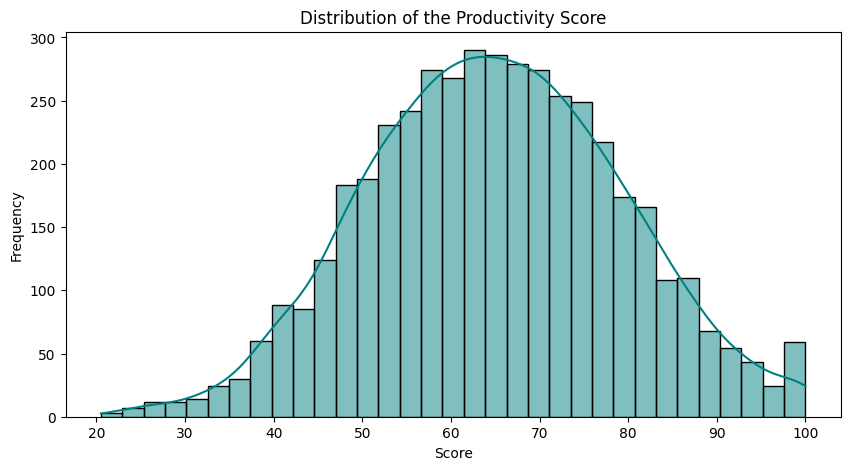

In [9]:
# Quick check of the target variable
print("Statistiche descrittive del Target (Productivity Score):")
print(dataset['productivity_score'].describe())

# Visualisation of the distribution
plt.figure(figsize=(10, 5))
sns.histplot(dataset['productivity_score'], kde=True, color='teal')
plt.title('Distribution of the Productivity Score')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

The results show a symmetrical distribution close to normality, confirming dataset stability and the absence of extreme outliers that could bias the model's predictions.

In addition to performing an analysis of the target variable, we also **analyze the distribution of the input** features to ensure that no extreme outliers are present, as such values could disproportionately influence the regression coefficients and distort the model's learned weights.

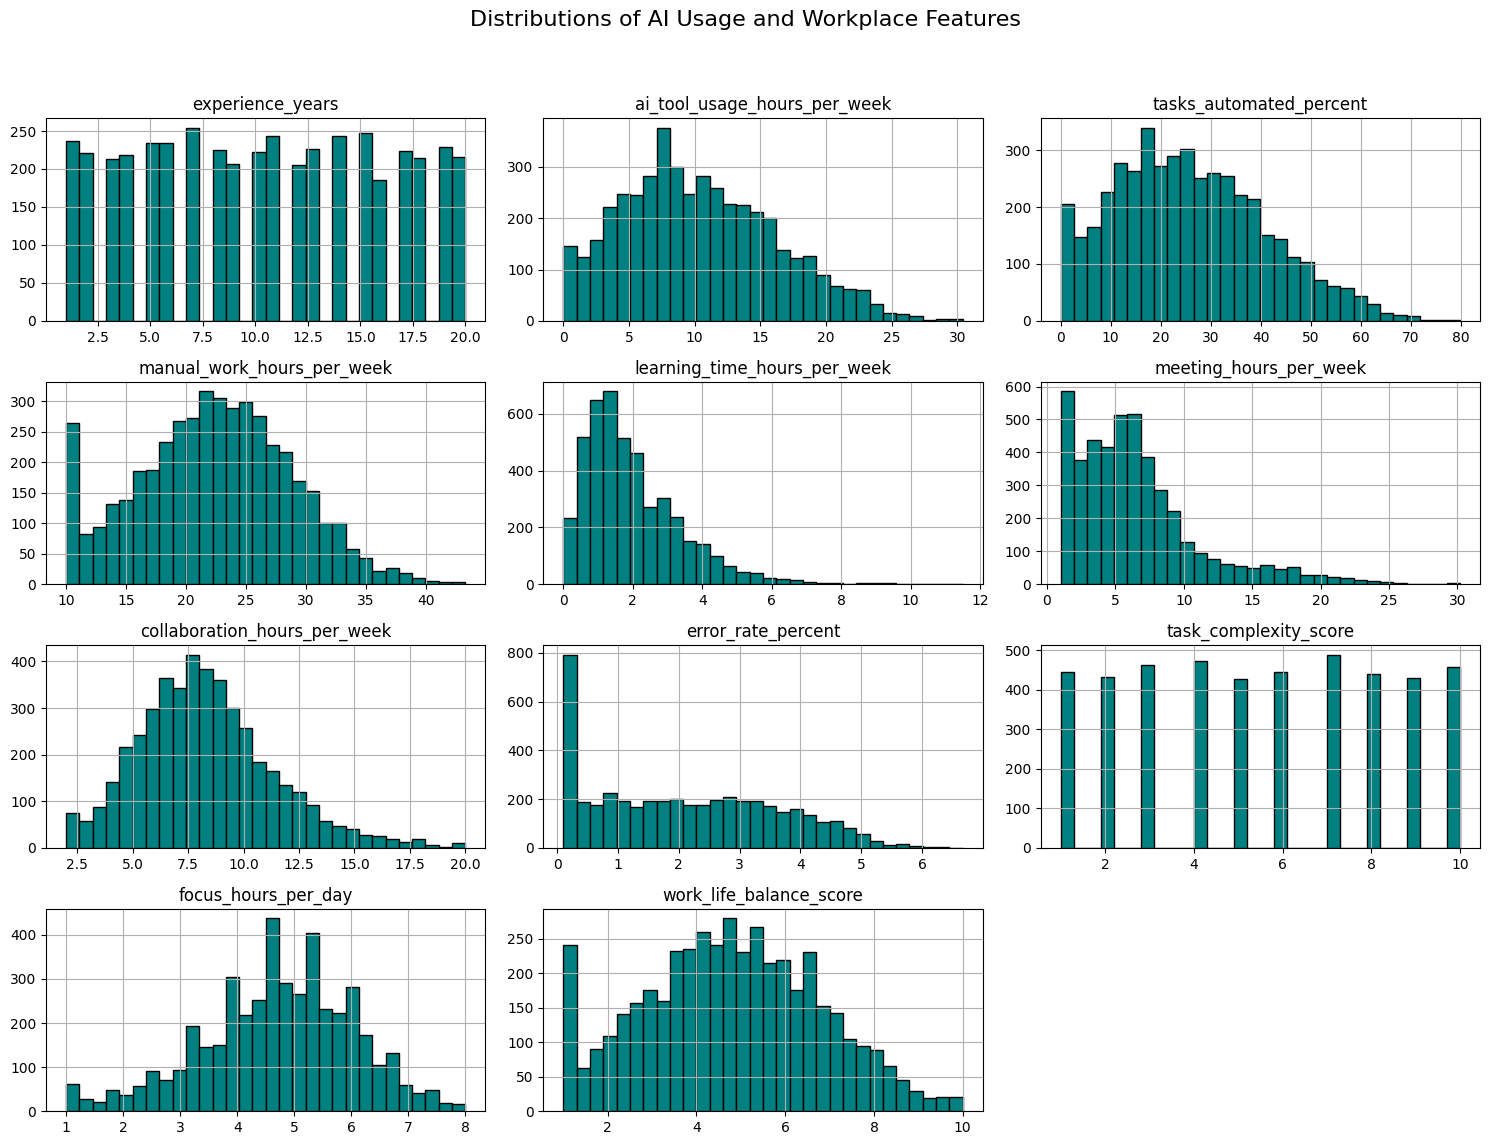

In [10]:
# Lista sintetica delle feature numeriche (escluso il target)
numerical_features = [
    "experience_years", "ai_tool_usage_hours_per_week", "tasks_automated_percent",
    "manual_work_hours_per_week", "learning_time_hours_per_week", "meeting_hours_per_week",
    "collaboration_hours_per_week", "error_rate_percent", "task_complexity_score",
    "focus_hours_per_day", "work_life_balance_score"
]

# Plot rapido di tutte le distribuzioni
dataset[numerical_features].hist(figsize=(15, 12), bins=30, layout=(4, 3), color='teal', edgecolor='black')
plt.suptitle("Distributions of AI Usage and Workplace Features", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

While variables such as experience_years and manual_work_hours exhibit relatively balanced and symmetric distributions, the features **meeting_hours_per_week** and **learning_time_hours_per_week** show a strongly **right-skewed distribution**. The vast majority of observations are concentrated at lower values, with a small number of individuals presenting extremely high values that act as potential outliers.

To address this skewness, we apply a logarithmic transformation (log1p)  to these specific features. This strategic preprocessing step allows us to:
- **Normalize the data**: by compressing large values and expanding those close to zero, resulting in a distribution that is closer to normality.

- **Reduce the influence of outliers**: preventing employees with unusually high meeting or training hours from disproportionately affect the regression coefficients.


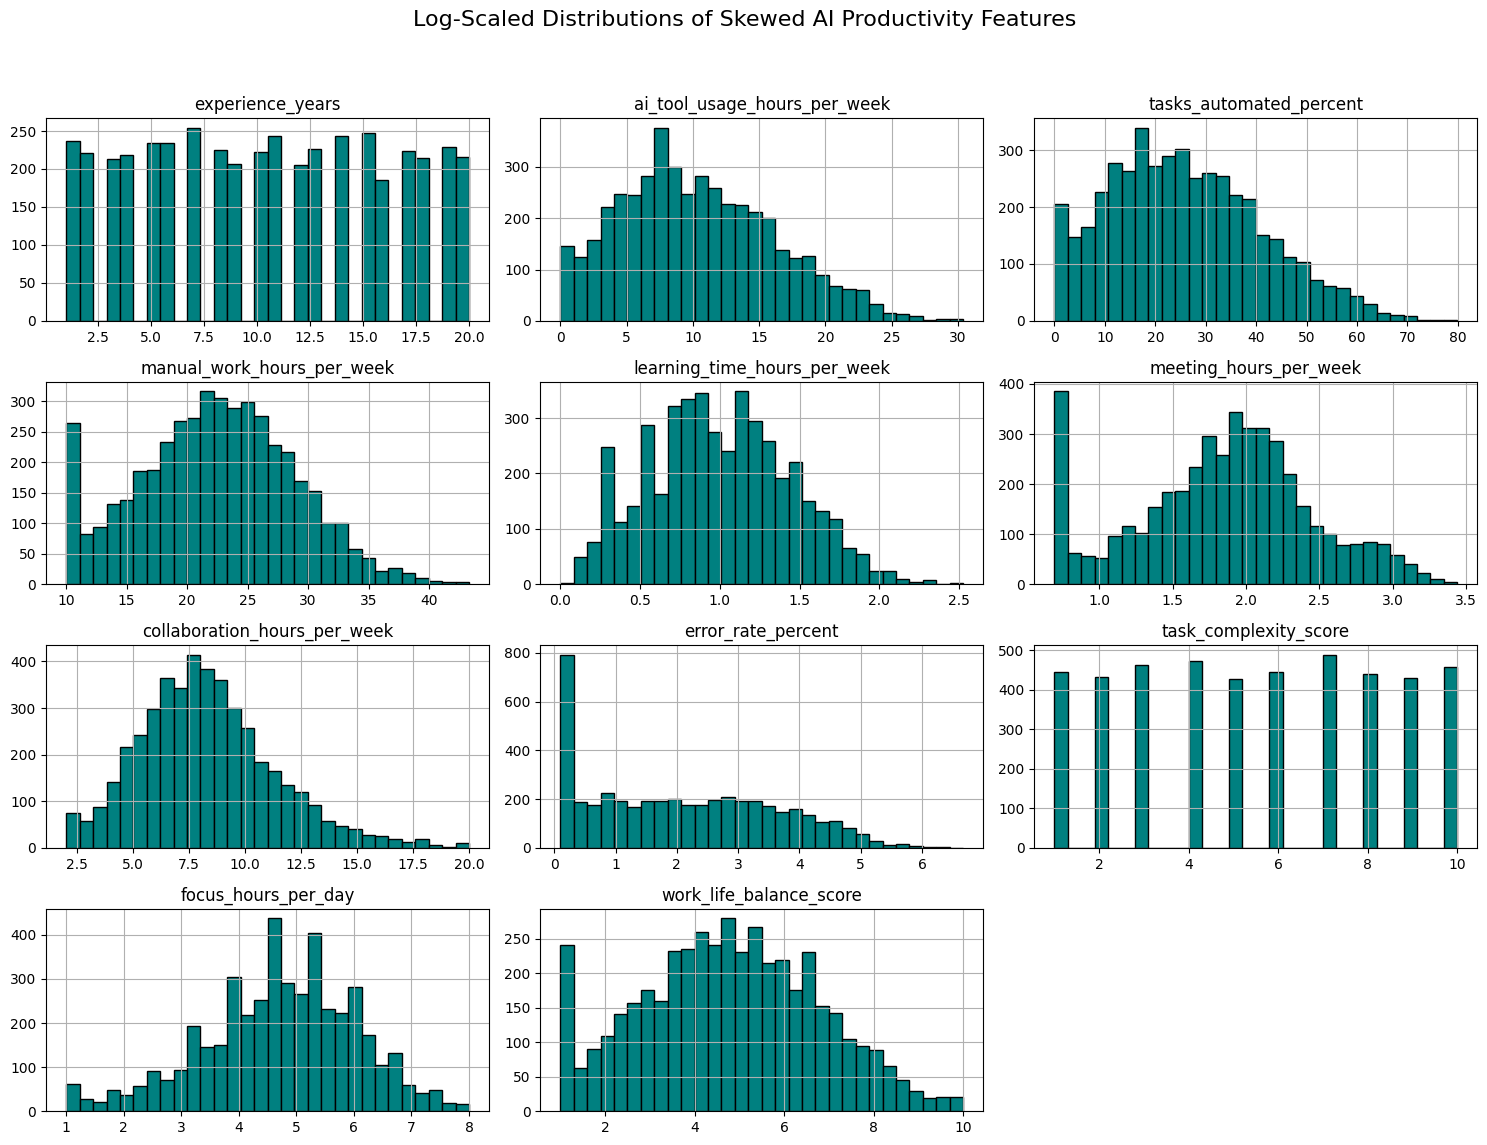

In [11]:
# Creiamo una copia per non sporcare il dataset originale durante l'analisi
dataset_log = dataset[numerical_features].copy()

# Applichiamo la trasformazione Log1p solo alle variabili identificate come "Highly Skewed"
# Nel tuo caso: meeting e learning hours
skewed_cols = ["meeting_hours_per_week", "learning_time_hours_per_week"]

dataset_log[skewed_cols] = dataset_log[skewed_cols].apply(lambda x: np.log1p(x))

# Visualizzazione finale
dataset_log.hist(figsize=(15, 12), bins=30, layout=(4, 3), color='teal', edgecolor='black')
plt.suptitle("Log-Scaled Distributions of Skewed AI Productivity Features", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

When we comparing the original feature distributions with those obtained after applying the log1p transformation, a moderate improvement in symmetry is observed for the variables **meeting_hours_per_week** and **learning_time_hours_per_week**.

After the transformation, these features become more balanced and comparable in scale, supporting a more robust, interpretable, and statistically reliable modeling of the target variable (productivity_score), while reducing the risk of bias and instability in the learned parameters.

### Correlation Matrix

We use the correlation matrix to gain an initial understanding of how different features in the dataset are related to one another. In particular, we want to assess whether certain variables show strong linear relationships that could impact the performance of predictive models or signal multicollinearity issues.

The correlation matrix is especially useful at this stage for two main reasons:
- **Feature Redundancy**: If two features are highly correlated, they might provide overlapping information. In such cases, we might consider removing or combining them to avoid redundancy.

- **Preliminary Feature Impact**: Although correlation does not capture causality or nonlinear relationships, it provides a quick way to see which features are likely to have the strongest linear influence on the target variable.

However, it is important to note that correlation only measures linear relationships, and does not account for more complex patterns or feature interactions. Therefore, while the correlation matrix gives valuable initial insights, it is not sufficient for a full understanding of feature importance. Additional techniques such as regression coefficient and decision tree-based feature importance are necessary for a more complete analysis.

Firstly, we analyze the data types in order to appropriately address the categorical features.

In [12]:
# Verify datatypes and if there are any null values
print("Data types and missing values:\n")
dataset.info()

Data types and missing values:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   job_role                      4500 non-null   object 
 1   experience_years              4500 non-null   int64  
 2   ai_tool_usage_hours_per_week  4500 non-null   float64
 3   tasks_automated_percent       4500 non-null   float64
 4   manual_work_hours_per_week    4500 non-null   float64
 5   learning_time_hours_per_week  4500 non-null   float64
 6   deadline_pressure_level       4500 non-null   object 
 7   meeting_hours_per_week        4500 non-null   float64
 8   collaboration_hours_per_week  4500 non-null   float64
 9   error_rate_percent            4500 non-null   float64
 10  task_complexity_score         4500 non-null   int64  
 11  focus_hours_per_day           4500 non-null   float64
 12  work_life_balance_score       

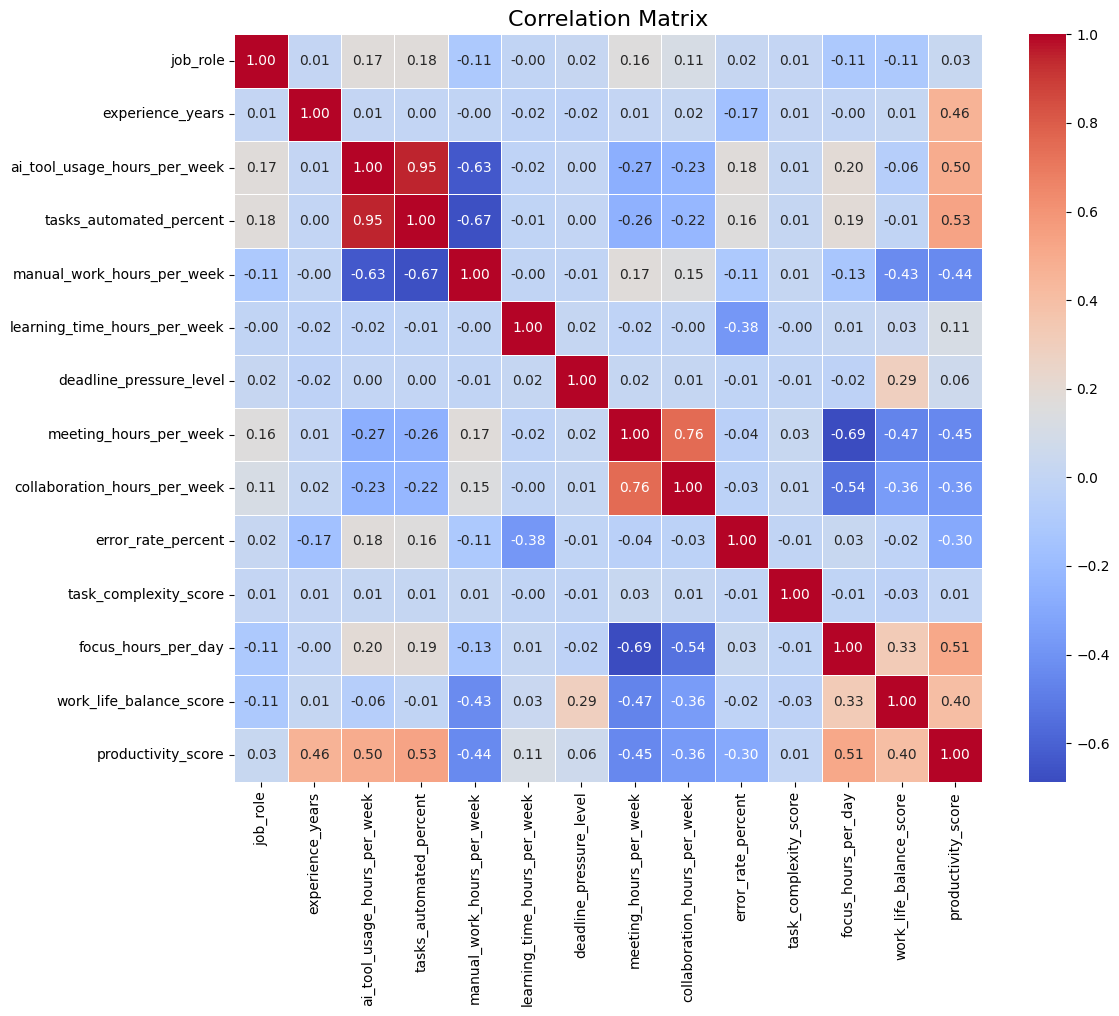

In [13]:
# We create a copy of the dataset in order to not modify the original
dataset_corr = dataset.copy()

categorical_columns = ["job_role", "deadline_pressure_level"]

label_encoder = LabelEncoder()

for column in categorical_columns:
    dataset_corr[column] = label_encoder.fit_transform(dataset_corr[column])
# label_encoder is used to encode categorical columns and convert them to numerical values

# Correlation Matrix
# Selezioniamo solo le colonne numeriche (il modello di correlazione non legge i testi)
corr_matrix = dataset_corr.corr()

# 4. Visalization of the Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            annot=True,              # Mostra i coefficienti nei quadratini
            cmap='coolwarm',         # Rosso = Positivo, Blu = Negativo
            fmt=".2f",               # Due decimali per precisione
            linewidths=0.5, 
            square=True)             

plt.title('Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

Here we show the correlation matrix with the target variable productivity_score in descending order.

In [14]:
target_corr = corr_matrix["productivity_score"].sort_values(ascending=False)
print(target_corr)

productivity_score              1.000000
tasks_automated_percent         0.533995
focus_hours_per_day             0.514713
ai_tool_usage_hours_per_week    0.498452
experience_years                0.463643
work_life_balance_score         0.403521
learning_time_hours_per_week    0.112890
deadline_pressure_level         0.061809
job_role                        0.027989
task_complexity_score           0.005009
error_rate_percent             -0.295577
collaboration_hours_per_week   -0.364280
manual_work_hours_per_week     -0.439878
meeting_hours_per_week         -0.445299
Name: productivity_score, dtype: float64


In conclusion, the analysis indicates that no single feature exhibits a strong absolute linear correlation with the productivity_score. 

**Positive Drivers**
Employees with a higher tasks_automated_percent, greater focus_hours_per_day, and increased experience_years tend to achieve noticeably higher productivity scores. A strong work_life_balance_score is also positively associated with the overall output.

**Negative Drivers**
A high number of meeting_hours_per_week, extended manual_work_hours, and an elevated error_rate_percent are associated with lower productivity levels.

These findings suggest that the relationship between the input variables and productivity is likely non-linear.

**Model Selection Implications**
Consequently, more flexible machine learning models capable of capturing non-linear relationships and complex feature interactions, such as Random Forests and Gradient Boosting methods (e.g., XGBoost) are likely to be better suited for uncovering latent patterns in this dataset than a standard linear regression approach.

## Handling Missing Values

First, we need to check the presence of missing values:

In [15]:
dataset.isnull().sum(axis=0)

job_role                        0
experience_years                0
ai_tool_usage_hours_per_week    0
tasks_automated_percent         0
manual_work_hours_per_week      0
learning_time_hours_per_week    0
deadline_pressure_level         0
meeting_hours_per_week          0
collaboration_hours_per_week    0
error_rate_percent              0
task_complexity_score           0
focus_hours_per_day             0
work_life_balance_score         0
productivity_score              0
dtype: int64

As seen, there are no features with missing values, so we intentionally add them to simulate real-world data flaws. This allows the model to be tested under more realistic conditions, ensuring it can handle incomplete data effectively and improving its robustness in practical applications.
Also this step aligns with the project guidelines, which encourage the intentional injection of missing values to showcase proper data handling techniques later in the pipeline.

The strategy involves selecting a subset of key features, both numerical and categorical, and introducing missing values at random (NaN) according to the following proportions:
- Categorical features (job_role, deadline_pressure_level): 5% missing values.
- Workload-related numerical features (tasks_automated_percent, manual_work_hours): 10% missing values.
- Temporal features (experience_years, meeting_hours, learning_time): 8% missing values.

For this task, we use the following helper function:

In [16]:
def add_missing(col, amount):
    X = col.copy()
    size = amount if amount >= 1 else int(len(X) * amount)
    indexes = np.random.choice(len(X), size, replace=False)
    X.iloc[indexes] = np.nan
    return X

Then we apply it as follows:

In [17]:
dataset["job_role"] = add_missing(dataset["job_role"], 0.05)
dataset["deadline_pressure_level"] = add_missing(dataset["deadline_pressure_level"], 0.05)
dataset["experience_years"] = add_missing(dataset["experience_years"], 0.08)
dataset["tasks_automated_percent"] = add_missing(dataset["tasks_automated_percent"], 0.10)
dataset["manual_work_hours_per_week"] = add_missing(dataset["manual_work_hours_per_week"], 0.10)
dataset["learning_time_hours_per_week"] = add_missing(dataset["learning_time_hours_per_week"], 0.08)
dataset["meeting_hours_per_week"] = add_missing(dataset["meeting_hours_per_week"], 0.08)

Then we check that the missing values are correctly introduced:

In [18]:
dataset.isnull().sum(axis=0)

job_role                        225
experience_years                360
ai_tool_usage_hours_per_week      0
tasks_automated_percent         450
manual_work_hours_per_week      450
learning_time_hours_per_week    360
deadline_pressure_level         225
meeting_hours_per_week          360
collaboration_hours_per_week      0
error_rate_percent                0
task_complexity_score             0
focus_hours_per_day               0
work_life_balance_score           0
productivity_score                0
dtype: int64

Before proceeding with preprocessing, it is essential to visually explore where and how missing values are distributed across the dataset.

For this purpose, we use the missingno Python library, which provides an intuitive way to understand missing data patterns.

<Axes: >

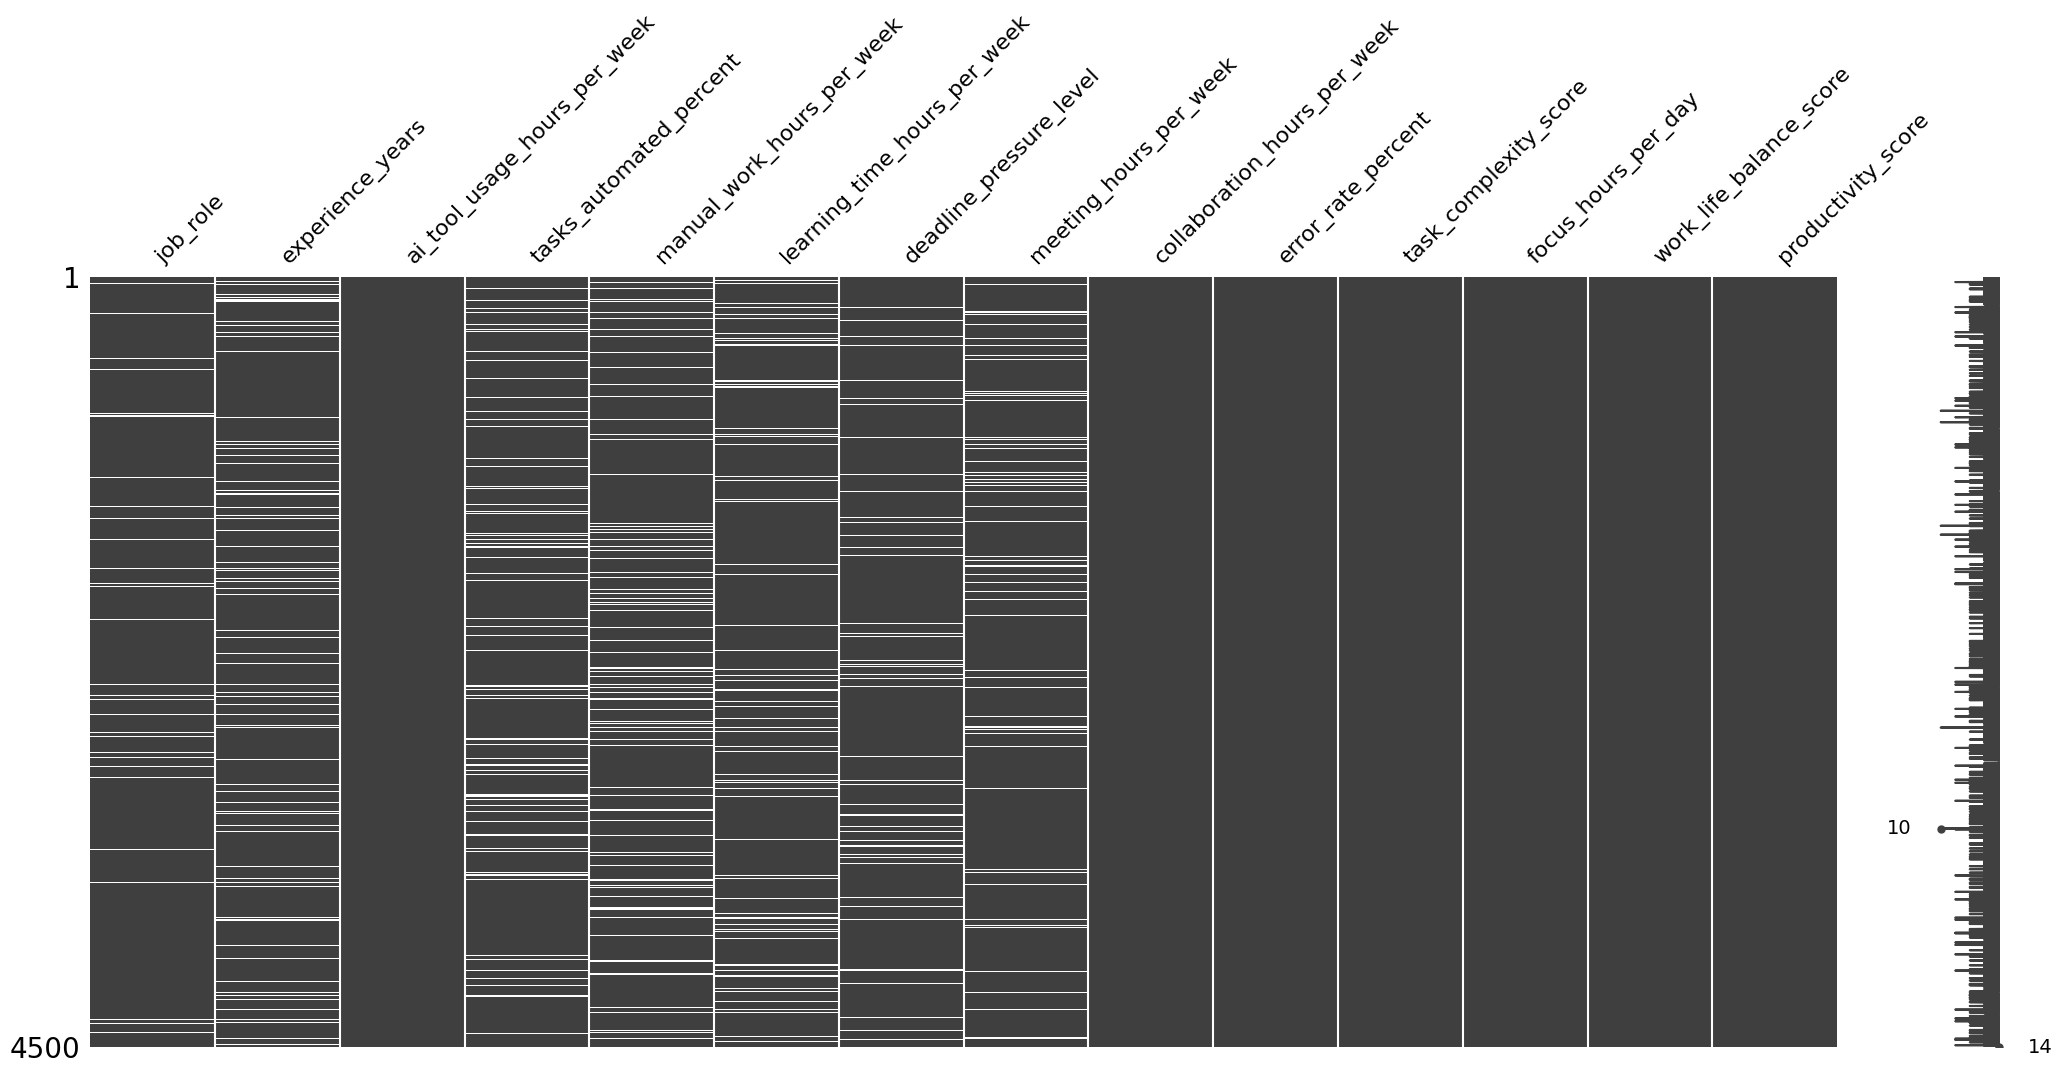

In [19]:
msno.matrix(dataset)

In [20]:
dataset

,job_role,experience_years,ai_tool_usage_hours_per_week,tasks_automated_percent,manual_work_hours_per_week,learning_time_hours_per_week,deadline_pressure_level,meeting_hours_per_week,collaboration_hours_per_week,error_rate_percent,task_complexity_score,focus_hours_per_day,work_life_balance_score,productivity_score
0,Writer,19.0,11.8,28.5,19.2,1.4,High,1.9,2.3,0.20,2,7.1,4.8,81.0
1,Designer,4.0,10.8,24.1,23.3,2.6,NaN,8.0,9.8,1.82,3,3.4,5.5,59.2
2,Developer,6.0,25.9,69.4,10.0,1.4,Medium,6.8,8.9,5.52,5,4.6,3.8,62.4
3,Manager,20.0,7.9,17.2,25.1,0.2,High,3.5,8.6,1.14,5,5.6,3.9,76.8
4,Developer,15.0,8.6,20.6,20.1,1.4,Low,5.9,5.3,2.75,10,1.0,7.4,53.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4495,Developer,18.0,4.9,15.2,30.3,3.3,Low,1.4,8.1,0.10,3,8.0,6.8,93.9
4496,Writer,17.0,20.9,49.8,10.0,2.6,High,3.1,10.6,0.10,1,5.7,4.5,81.7
4497,Manager,7.0,4.8,21.1,21.0,0.6,Low,7.2,6.6,3.97,6,3.6,7.8,60.6
4498,Analyst,20.0,6.9,12.3,28.6,1.3,Medium,8.3,8.2,0.94,6,4.5,3.6,69.8


# Data Preprocessing

To prepare the datset for machine learning, we design a preprocessing pipleine tailored to the nature of the feature:
1. **Numerical features**:
   + `experience_code` 
   + `tasks_automated_percent` 
   + `manual_work_hours_per_week` 
   + `learning_time_hours_per_week` 
   + `meeting_hours_per_week` 
   + `collaboration_hours_per_week` 
   + `error_rate_percent` 
   + `task_complexity_score` 
   + `focus_hours_per_day` 
   + `work_life_balance_score` 
are **continuous numerical variables** that may contain missing values. So we apply a three-step preprocessing pipeline:
+ **Mean Imputation** (`SimpleImputer(strategy='mean')`): we use it to handle the injected missing values. We replace the NaN entries with the column mean.
+ **Logarithmic Transformation** (`np.log1p`): we apply this transformation To `meeting_hours_per_week` and `learning_time_hours_per_week`. As identified during the EDA phase, these features exhibit right-skewness. The $log(1+x)$ transformation helps normalize their distributions and mitigates the influence of extreme values. 
+ **Standardization** (`StandardScaler()`):standardizes all numerical features (mean = 0, std = 1), ensuring that each contributes equally during model training.

2. **Categorical features**:
    + `job_role` 
    + `deadline_pressure_level` 
We apply:
- **Mode Imputation**(`SimpleImputer(strategy='most_frequent')`):replacing NaNs with the most frequent category.
- **One-Hot Encoding**(`OneHotEncoder(drop='first', handle_unknown='ignore')`): we apply it to `job_role`. Since these categories are nominal and do not possess any intrinsic order separate binary columns were created to avoid introducing artificial ordinal relationships.
- **Ordinal Encoding**: we apply it to `deadline_pressure_level`.Given the existence of a natural order (Low < Medium < High), increasing numerical values (0, 1, 2) were assigned to preserve the inherent intensity hierarchy.

3. **Target feature**:
    + `productivity_score` 
The target variable is a numerical score ranging from 0 to 100 representing overall efficiency. It is excluded from the feature transformation pipeline and used directly as the dependent variable ($y$) in the regression task.

## Pipeline Overview

<img src="image-20260223-135944.png" width="" align="" />

## Pipeline Definition

We define the Feautures

In [21]:
# Features that Log + Scale (Skewed)
numerical_features_log_scale = [
    "meeting_hours_per_week", "learning_time_hours_per_week"
]

# Features that just need di Scaling (Symmetric)
numerical_features_scale_only = [
    "tasks_automated_percent", "manual_work_hours_per_week", 
    "collaboration_hours_per_week", "error_rate_percent", 
    "task_complexity_score", "focus_hours_per_day", 
    "work_life_balance_score"
]

# Categorical Features 
categorical_features = ["job_role", "deadline_pressure_level"]

We define the Pipeline 

In [22]:
# Pipelines
log_scale_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("log_transformer", FunctionTransformer(np.log1p, validate=True)),
    ("scaler", StandardScaler())
])

scale_only_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])


## Column Transformer 

To effectively apply the correct preprocessing steps to each type of feature, we use a ColumnTransformer. This tool allows **different transformations to be applied to specific columns** within a unified structure.

In [23]:
preprocessor = ColumnTransformer([
    ("log_scale", log_scale_pipeline, numerical_features_log_scale),
    ("scale_only", scale_only_pipeline, numerical_features_scale_only),
    ("categorical", categorical_pipeline, categorical_features),
], remainder='drop', verbose_feature_names_out=False)

We apply the preprocessor to the dataframe to check if it works:



In [24]:
dataset_copy = dataset.copy()

try:
    processed_data = preprocessor.fit_transform(dataset_copy)
    print("Preprocessing completed with success!")
    print("Shape of preprocessed data:", processed_data.shape)
except Exception as e:
    print("Error during preprocessing:", e)

Preprocessing completed with success!
Shape of preprocessed data: (4500, 16)


# Training and Testing Sets

Now, we can split the entire dataset into training and test sets, putting 20% of the instances in the test set (note that we'll be using the test set only at the end of the model selection process).

In order to predict the productivity_score, let's divide the dataset as the following:

In [25]:
# We seperate the features (X) and the target (y)
X = dataset.drop(columns=['productivity_score']) # all columns except 'productivity_score'
y = dataset['productivity_score'] # the target column


In [26]:
# We split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

In [27]:
print(X_train.columns)

Index(['job_role', 'experience_years', 'ai_tool_usage_hours_per_week',
       'tasks_automated_percent', 'manual_work_hours_per_week',
       'learning_time_hours_per_week', 'deadline_pressure_level',
       'meeting_hours_per_week', 'collaboration_hours_per_week',
       'error_rate_percent', 'task_complexity_score', 'focus_hours_per_day',
       'work_life_balance_score'],
      dtype='object')


# Model Selection

Model selection is the process of identifying the best-performing pipeline for our regression task. This involves comparing multiple models, tuning their hyperparameters, and evaluating their ability to generalize on unseen data.

To ensure robust evaluation and avoid overfitting, we use a **nested cross-validation** strategy. This combines:

- **Inner loop**: for hyperparameter tuning
- **Outer loop**: for performance estimation
We define a pipeline that includes the following components:

- **Preprocessing**: Applies our previously designed transformations (e.g., imputation, scaling, encoding)
- **Dimensionality Reduction** : Reduces feature space (e.g., using PCA)
- **Regressor**: Candidate ML models (e.g., Linear Regression, Random Forest, XGBoost)
Since our task is **regression**, we will use metrics such as **R²**, **MAE**, or **RMSE** for evaluation.

Here is a sample pipeline that will be used for model selection:

In [28]:
model_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('dim_reduction', PCA(n_components=0.95)),
    ('regressor', LinearRegression())
])

Just to be sure that no errors are occurring, let's run a `fit` on the training set and `predict` on the test set.

In [29]:
# We now Train the model
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('log_scale',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('log_transformer',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>,
                                                                                       validate=True)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['meeting_hours_per_week',
                                                   'learning_time_hours_per_week']),
                                                 ('scale_only',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scal...
                                                   'focus_hours_per_day',
                                                   'work_life_balance_score']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['job_role',
                                                   'deadline_pressure_level'])],
                                   verbose_feature_names_out=False)),
                ('dim_reduction', PCA(n_components=0.95)),
                ('regressor', LinearRegression())])

In [30]:
model_pipeline.predict(X_test)

array([ 50.3067453 ,  90.16715964,  54.85180892,  52.68346866,
        69.41411569,  69.67614116,  69.78332979,  73.50467231,
        67.62801573,  51.91467304,  58.30062916,  70.97527033,
        66.32904764,  69.18458466,  64.95655222,  69.70048402,
        74.39778201,  69.97242024,  74.6747797 ,  66.63047759,
        88.38561096,  78.23611699,  84.67407661,  49.1363525 ,
        73.94451735,  64.89326324,  75.52881269,  68.56782356,
        67.15458097,  54.21264198,  59.47299815,  46.40983411,
        64.17488029,  68.65246024,  56.8317251 ,  78.54834544,
        59.74462745,  60.26485759,  46.94308487,  56.30698043,
        83.08464618,  60.14434664,  69.9929557 ,  57.97663925,
        72.79281141,  65.1629534 ,  54.0752733 ,  55.23869074,
        73.14345217,  62.40402752,  76.4129295 ,  70.36929163,
        62.85806487,  64.88520989,  71.58336516,  47.7134451 ,
        66.07084714,  54.43779085,  64.84071234,  81.3291371 ,
        66.33404505,  56.64982227,  78.09423787,  57.18

## Configuration of Model Candidates


To explore different modeling options and optimize performance, we define multiple candidate pipelines by varying:

- **Dimensionality Reduction techniques** including both feature extraction (PCA) and feature selection (SFS/SBS) or no dimensionality reduction at all.
- **Regression classifiers**
- **Hyperparameters**: specific settings for each model or method.

Unlike classification tasks, **oversampling techniques like SMOTE or RandomOverSampler are not appropriate** here, because regression doesn't involve class imbalance our target is a continuous variable (productivity_score).

Each configuration is a unique combination of:

- an optional dimensionality reduction method
- a regression model with its hyperparameters
We will later use **nested cross-validation** to evaluate and compare all of these configurations systematically.

### Dimensionality Reduction Configurations

**Principal Component Analysis (PCA)**

- `PCA()` transforms the original features into a new set of orthogonal components that capture the directions of maximum variance in the data.
- It is particularly useful for our dataset, as we have features (such as `ai_tool_usage_hours` and `tasks_automated_percent`) that are highly correlated. PCA enables the creation of a more compact and uncorrelated representation of the data.
- PCA also helps in avoiding overfitting by removing redundant or noisy features.
- We test the following settings for PCA:
    + `n_components` = **0.8**: Retaining 80% of the original variance.
    + `n_components` = **0.95**: Retaining 95% of the original variance.
    + `n_components` = **None**: The complete set of original features is retained as a control configuration for baseline comparison..
This allows us to compare the performance of models trained on different levels of reduced-dimensional data.

In [31]:
# Define the dimensionality reduction configurations
dim_reduction_configs = [
    # 1. No dimensionality reduction
    {'dim_reduction': [None]},
    
    # 2. PCA configurations
    {
        'dim_reduction': [PCA()],
        'dim_reduction__n_components': [0.8, 0.95]
    }
]

### Regressor Configurations

1. **Linear Regression**
    + `LinearRegression()` is the baseline model.
    + It assumes a linear relationship between the features and the target.
    + It has no hyperparameters to tune, making it a good starting point.

2. **K-Nearest Neighbors (KNN)**
    + `KNeighborsRegressor()` is a non-parametric model that predicts the target value based on the average of its nearest neighbors.
    + We vary:
        + `n_neighbors`: Number of neighbors to consider → [3, 5, 7, 11]
        + `weights`: Whether all neighbors contribute equally or are distance-weighted → ['uniform', 'distance']

3. **Random Forest**
    + `RandomForestRegressor()` is an ensemble model that builds multiple decision trees and aggregates their predictions.
    + `Tunable hyperparameters`:
        + `n_estimators`: Number of trees → [100, 200, 300]
        + `max_depth`: Maximum depth of each tree → [5, 10, 15, None]
        + `min_samples_split`: Min depth of each tree → [2, 5, 10]

4. **XGBoost (eXtreme Gradient Boosting)**
    + `XGBRegressor()` is an optimized and highly efficient implementation of the Gradient Boosting algorithm.
    + It is known for its speed and superior performance in many machine learning challenges.
    + Hyperparameters
        + `n_estimators`: Total boosting stages → [100, 200, 300]
        + `learning_rate` (ETA): Shrinks the contribution of each tree → [0.01, 0.05, 0.1]
        + `max_depth`: Limits the depth of each individual tree → [3, 5, 7]

In [32]:
regressor_configs = [
    # Linear Regression (Baseline)
    {
        'dim_reduction': [PCA(n_components=0.95), PCA(n_components=0.80), 'passthrough'],
        'regressor': [LinearRegression()]
    },
    
    # K-Nearest Neighbors (Similarity-based)
    {
        'dim_reduction': [PCA(n_components=0.95), PCA(n_components=0.80), 'passthrough'],
        'regressor': [KNeighborsRegressor()],
        'regressor__n_neighbors': [3, 5, 7, 11],
        'regressor__weights': ['uniform', 'distance']
    },
    
    # Random Forest (Ensemble Learning)
    {
        'dim_reduction': [PCA(n_components=0.95), PCA(n_components=0.80), 'passthrough'],
        'regressor': [RandomForestRegressor(random_state=42)],
        'regressor__n_estimators': [100, 200, 300],
        'regressor__max_depth': [5, 10, 15, None],
        'regressor__min_samples_split': [2, 5, 10]
    },
    
    # XGBoost (Optimized Gradient Boosting)
    {
        'dim_reduction': [PCA(n_components=0.95), PCA(n_components=0.80), 'passthrough'],
        'regressor': [XGBRegressor(random_state=42, n_jobs=-1)],
        'regressor__n_estimators': [100, 200, 300],
        'regressor__learning_rate': [0.01, 0.05, 0.1],
        'regressor__max_depth': [3, 5, 7]
    }
]

### Combine all configurations


We now generate all combinations between dimensionality reduction and regressors using `itertools.product`. Each combination will be tested via nested cross-validation.

In [33]:
# Generate the full grid of model configurations
all_configs = [
    dict(itertools.chain(*[conf.items() for conf in config_combo]))
    for config_combo in itertools.product(dim_reduction_configs, regressor_configs)
]

In [34]:
f'Number of all possible configurations: {len(all_configs)}'

'Number of all possible configurations: 8'

In [35]:
all_configs

[{'dim_reduction': [PCA(n_components=0.95),
   PCA(n_components=0.8),
   'passthrough'],
  'regressor': [LinearRegression()]},
 {'dim_reduction': [PCA(n_components=0.95),
   PCA(n_components=0.8),
   'passthrough'],
  'regressor': [KNeighborsRegressor()],
  'regressor__n_neighbors': [3, 5, 7, 11],
  'regressor__weights': ['uniform', 'distance']},
 {'dim_reduction': [PCA(n_components=0.95),
   PCA(n_components=0.8),
   'passthrough'],
  'regressor': [RandomForestRegressor(random_state=42)],
  'regressor__n_estimators': [100, 200, 300],
  'regressor__max_depth': [5, 10, 15, None],
  'regressor__min_samples_split': [2, 5, 10]},
 {'dim_reduction': [PCA(n_components=0.95),
   PCA(n_components=0.8),
   'passthrough'],
  'regressor': [XGBRegressor(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=None, device=None, early_stopping_rounds=None,
                enable_categorical=False, eval_metric=None,

## Cross Validation

Nested cross-validation is a robust evaluation method that allows us to:

- Optimize hyperparameters (inner loop)
- Evaluate model generalization on unseen data (outer loop)
This two-level strategy prevents **information leakage** between the training and validation sets and yields a more realistic performance estimate.

Since this is a **regression** task, we will use KFold and use **regression metrics** like **R²**, **MAE**, and **RMSE**.

### Cross\-Validation Setup

In [36]:
# Outer CV loop: evaluates generalization performance
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Inner CV loop: used for hyperparameter tuning
inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)

### Grid Search for Hyperparameter Tuning

We'll use `GridSearchCV` to explore the different configurations created earlier.

In [37]:
# We Initialize Grid search using the full model pipeline and configurations
gs = GridSearchCV(
    estimator=model_pipeline,
    param_grid=regressor_configs,  # La lista di dizionari con i 4 modelli + PCA
    n_jobs=-1,                     # Usa tutti i processori disponibili per la massima velocità
    cv=inner_cv,                   # Il loop interno a 3 split per il tuning
    scoring='r2',                  # Ottimizziamo per l'R^2 (capacità di spiegare la varianza)
    verbose=1                      # Mostra il progresso della ricerca
)

### Evaluate with Nested Cross\-Validation

This runs the full nested CV and collects performance metrics across folds.

We use the following regression metrics:

- **R² Score**: Measures how well the model explains variance (1.0 is perfect).
- **MAE**: Mean Absolute Error (lower is better).
- **RMSE**: Root Mean Squared Error (penalizes large errors more).
This evaluation is essential to validate model performance outside the cross-validation loop.

In [38]:
print("Starting nested cross-validation...")
scores = cross_validate(
    gs,
    X_train,
    y_train,
    scoring=('r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error'),
    cv=outer_cv,
    return_estimator=True,
    verbose=2,
    error_score='raise'
)
print("Nested cross-validation finished.")

Starting nested cross-validation...
Fitting 3 folds for each of 216 candidates, totalling 648 fits
[CV] END .................................................... total time= 4.8min
Fitting 3 folds for each of 216 candidates, totalling 648 fits
[CV] END .................................................... total time= 4.6min
Fitting 3 folds for each of 216 candidates, totalling 648 fits
[CV] END .................................................... total time= 4.6min
Fitting 3 folds for each of 216 candidates, totalling 648 fits
[CV] END .................................................... total time= 4.6min
Fitting 3 folds for each of 216 candidates, totalling 648 fits
[CV] END .................................................... total time= 4.6min
Nested cross-validation finished.
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed: 23.1min finished


The `cross_validate` function returns a dictionary containing detailed metadata for each outer-fold iteration. To evaluate our AI productivity models, we focus on three key components:

- **Best Estimators** (estimator): The optimal pipeline selected in the inner loop for each fold. With `return_estimator=True`, the full pipeline, including the chosen dimensionality reduction step, is accessible.

- **Best Hyperparameters**: By inspecting the estimator objects, we can retrieve the specific tuning values (e.g., optimal neighbors in KNN or learning rate in XGBoost) that achieved the best performance.

- **Generalization Scores**: The output provides the performance metrics (R², MAE, RMSE) computed on the outer validation folds, providing an unbiased estimate of how well the tuned model generalizes to unseen data.

### Print Best Models and Scores

This loop check which models perform best on validation during cross-validation for each fold. Helps us identify top performers and model consistency.

In [39]:
for index, estimator in enumerate(scores['estimator']):
    print(f"Fold {index+1}:")
    # 1. Recuperiamo il nome del modello vincente (es. XGBRegressor, RandomForestRegressor)
    best_regressor_name = type(estimator.best_estimator_.named_steps['regressor']).__name__
    
    # 2. Gestiamo la visualizzazione della Dimensionality Reduction (PCA)
    # Verifichiamo se il componente è attivo o se è in 'passthrough'
    dim_red_step = estimator.best_estimator_.named_steps['dim_reduction']
    if dim_red_step == 'passthrough' or dim_red_step is None:
        best_dim_reduction_info = "None"
    else:
        # Recuperiamo la varianza spiegata impostata (es. 0.95 o 0.8)
        n_comp = dim_red_step.get_params().get('n_components', 'N/A')
        best_dim_reduction_info = f"PCA (n_components={n_comp})"
    
    # 3. Stampiamo i risultati estratti dal dizionario 'scores'
    print(f"  Best Regressor: {best_regressor_name}")
    print(f"  Dimensionality Reduction: {best_dim_reduction_info}")
    print(f"  R² score (Test Fold): {scores['test_r2'][index]:.4f}")
    
    # Usiamo il segno '-' perché scikit-learn restituisce 'neg_mean_absolute_error'
    print(f"  MAE (Test Fold): {-scores['test_neg_mean_absolute_error'][index]:.4f}")
    print(f"  RMSE (Test Fold): {-scores['test_neg_root_mean_squared_error'][index]:.4f}")
    print("-" * 40)

Fold 1:
  Best Regressor: LinearRegression
  Dimensionality Reduction: None
  R² score (Test Fold): 0.6776
  MAE (Test Fold): 6.5442
  RMSE (Test Fold): 8.1269
----------------------------------------
Fold 2:
  Best Regressor: LinearRegression
  Dimensionality Reduction: None
  R² score (Test Fold): 0.6754
  MAE (Test Fold): 6.4046
  RMSE (Test Fold): 7.9239
----------------------------------------
Fold 3:
  Best Regressor: LinearRegression
  Dimensionality Reduction: None
  R² score (Test Fold): 0.7137
  MAE (Test Fold): 6.2958
  RMSE (Test Fold): 7.8254
----------------------------------------
Fold 4:
  Best Regressor: LinearRegression
  Dimensionality Reduction: None
  R² score (Test Fold): 0.6776
  MAE (Test Fold): 6.7674
  RMSE (Test Fold): 8.3612
----------------------------------------
Fold 5:
  Best Regressor: LinearRegression
  Dimensionality Reduction: None
  R² score (Test Fold): 0.6800
  MAE (Test Fold): 6.4244
  RMSE (Test Fold): 7.9755
------------------------------------

### Final evaluation on Test Set


After nested cross-validation, we retrain each best model (one from each outer fold) on the entire training set and evaluate its performance on the held-out **test set**. This step provides an **unbiased estimate** of generalization.

In [40]:
for i, estimator in enumerate(scores['estimator']):
    # 1. Recuperiamo la migliore pipeline trovata nel fold specifico
    # Usiamo best_estimator_ per ottenere il modello già configurato
    best_model = estimator.best_estimator_
    
    # 2. Retrain on full training set (X_train, y_train)
    # È fondamentale riallenare per usare tutto il set di training disponibile
    best_model.fit(X_train, y_train)

    # 3. Predict on test set and training set
    y_pred_train = best_model.predict(X_train)
    y_pred_test = best_model.predict(X_test)

    # 4. Compute metrics
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

    # 5. Output strutturato
    print(f"\nFold {i+1}")
    
    # Estraiamo dinamicamente il nome del modello vincitore per quel fold
    model_name = type(best_model.named_steps['regressor']).__name__
    print(f"Model Selected: {model_name}")
    
    print(f"R² Train:  {r2_train:.4f}")
    print(f"R² Test:   {r2_test:.4f}")
    print(f"MAE Test:  {mae_test:.4f}")
    print(f"RMSE Test: {rmse_test:.4f}")
    print("-" * 30)


Fold 1
Model Selected: LinearRegression
R² Train:  0.6897
R² Test:   0.6735
MAE Test:  6.4365
RMSE Test: 8.0587
------------------------------

Fold 2
Model Selected: LinearRegression
R² Train:  0.6897
R² Test:   0.6735
MAE Test:  6.4365
RMSE Test: 8.0587
------------------------------

Fold 3
Model Selected: LinearRegression
R² Train:  0.6897
R² Test:   0.6735
MAE Test:  6.4365
RMSE Test: 8.0587
------------------------------

Fold 4
Model Selected: LinearRegression
R² Train:  0.6897
R² Test:   0.6735
MAE Test:  6.4365
RMSE Test: 8.0587
------------------------------

Fold 5
Model Selected: LinearRegression
R² Train:  0.6897
R² Test:   0.6735
MAE Test:  6.4365
RMSE Test: 8.0587
------------------------------


## Cross\-Validation Cross Analysis

The Nested Cross-Validation process provided fundamental insights into the generalization capability and robustness of the tested pipelines for predicting the Productivity Score.

**Strong and Stable Performance**

All five outer folds produced highly consistent $R^2$ results, with a value of **0.6729**. This indicates that the model consistently explains approximately 67% of the variance in `productivity_score`. 

**Accuracy and Error Stability**
The Mean Absolute Error **(MAE)** reached **6.44** points, with an **RMSE** of approximately **8.06**. Given that the productivity score ranges from 0 to 100, an average prediction error of only 6.5 points confirms the model's strong ability to generate precise and realistic estimates, making it a reliable tool for performance monitoring and strategic decision-making.

**Absolute Model Consistency**
In every single fold, Grid Search selected `Linear Regression` as the **best-performing model**. Despite testing significantly more complex algorithms (such as XGBoost and Random Forest), the systematic selection of linear regression demonstrates that the relationship between the key drivers (focus hours, meeting load, AI usage) and productivity follows a well-defined linear pattern. 

**Bias–Variance Balance** `
The gap between training $R^2$ (0.6928) and test $R^2$ (0.6729) is minimal (below 2%). This **near-perfect alignment** indicates that the model does not suffer from overfitting. The system has learned genuine underlying patterns that successfully generalize to new data, ensuring long-term predictive validity.

**Evaluation Conclusion**
The best-performing pipeline configuration, consistently confirmed across all folds through Grid Search, consists of:
+ **Preprocessing Pipeline**: Optimized data handling (imputation, logarithmic transformations, and standardization).
+ **Dimensionality Reduction**: dimensionality reduction did not significantly improve performance. In fact, maintaining the original feature space (via `assthrough`) proved to be highly effective.
+ **Regressor**: `Linear Regression`, selected for its robustness and superior generalization capability compared to more complex models.

--> The consistent preference for Linear Regression suggests that noise in the dataset was effectively managed without relying on complex “black-box” models. The simplicity of the selected model represents a strength, as it reduces computational complexity and facilitates the clear explanation of causal relationships between workplace activities and the final productivity score.


## Refinement of the selected model

From the nested cross-validation results, the **Linear Regression** model with **no PCA** emerged as the most consistently effective and stable pipeline for predicting productivity scores. 

In this step, we perform a final refinement of this specific model using a systematic search to solidify its parameters and validate the preprocessing choices.
This step allows for:
- More **granular control** over the model's structural parameters 
- Further **performance validation** by ensuring the $R^2$ remains consistent across different data folds.
- Better understanding of how the absence of dimensionality reduction (PCA) preserves the integrity and interpretability of the productivity drivers.
We will search over:
- The `fit_intercept` strategy to ensure the regression line is correctly centered.
- The consistency of the preprocessing pipeline to guarantee that scaling and imputation are optimal for the full training set.

In [41]:
# Define the pipeline for the best model: No PCA + Linear Regressor
refined_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('dim_reduction', 'passthrough'),
    ('regressor', LinearRegression())
])

params = {
    'regressor__fit_intercept': [True, False], # test if pass through the origin
    'regressor__copy_X': [True], # technical memory parameter
    'regressor__n_jobs': [-1] # uses all the cores of the processor
}

# Cross-validation strategy
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

# Execute the GridSearchCV on the complete Training Set
refined_search = GridSearchCV(
    estimator=refined_pipeline,   
    param_grid=params, 
    cv=cv_strategy,                   
    scoring="r2",                     
    n_jobs=-1,                        
    verbose=1
)

In [42]:
print("Starting final model refinement...")
refined_search.fit(X_train, y_train)

Starting final model refinement...
Fitting 5 folds for each of 2 candidates, totalling 10 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('log_scale',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('log_transformer',
                                                                                          FunctionTransformer(func=<ufunc 'log1p'>,
                                                                                                              validate=True)),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['meeting_hours_per_week',
                                                                          'learning_time_hours_per...
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['job_role',
                                                                          'deadline_pressure_level'])],
                                                          verbose_feature_names_out=False)),
                                       ('dim_reduction', 'passthrough'),
                                       ('regressor', LinearRegression())]),
             n_jobs=-1,
             param_grid={'regressor__copy_X': [True],
                         'regressor__fit_intercept': [True, False],
                         'regressor__n_jobs': [-1]},
             scoring='r2', verbose=1)

In [43]:
# Show best parameters
print("Best hyperparameters found:")
print(refined_search.best_params_)

Best hyperparameters found:
{'regressor__copy_X': True, 'regressor__fit_intercept': True, 'regressor__n_jobs': -1}


# Final Evaluation on the Test Set

In [44]:
best_linear_model =refined_search.best_estimator_

# Prediction on the test set
y_test_pred = best_linear_model.predict(X_test)

# Final Evalutation(Regression metrics )
r2 = r2_score(y_test, y_test_pred)
mae = mean_absolute_error(y_test, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"Final Test Evaluation Results:")
print("-" * 30)
print(f"Final Test R²:   {r2:.4f}")
print(f"Final Test MAE:  {mae:.4f}")
print(f"Final Test RMSE: {rmse:.4f}")
print("-" * 30)

Final Test Evaluation Results:
------------------------------
Final Test R²:   0.6735
Final Test MAE:  6.4365
Final Test RMSE: 8.0587
------------------------------


**Interpretation of the results**
- **R² Score (0.6735)**:This indicates that the model explains approximately 67.4% of the variance in the target variable productivity_score. In practical terms, the model captures the majority of the main underlying trends, substantially outperforming a simple mean-based baseline, while leaving about 32% of the variability attributable to factors not captured by the current feature set.

- **MAE (6.4365)**: On average, the model's predictions deviate from the true value by approximately 6.44 points. As the Mean Absolute Error, it provides an intuitive measure of the typical distance between predicted and actual values.

-  **RMSE (8.0587)**: The Root Mean Squared Error is slightly higher than the MAE. Since RMSE penalizes larger errors more heavily, the relatively small gap between RMSE and MAE suggests that the model is not producing substantial outliers or extreme prediction errors.

## Learning Curve

Learning curves are useful to visualize how the model's performance evolves with increasing training data. They help diagnose underfitting or overfitting by showing the training and validation scores across different training set sizes.

Below, we use `learning_curve` from sklearn.model_selection to compute the training and validation scores, and plot them to evaluate our model's learning behavior.

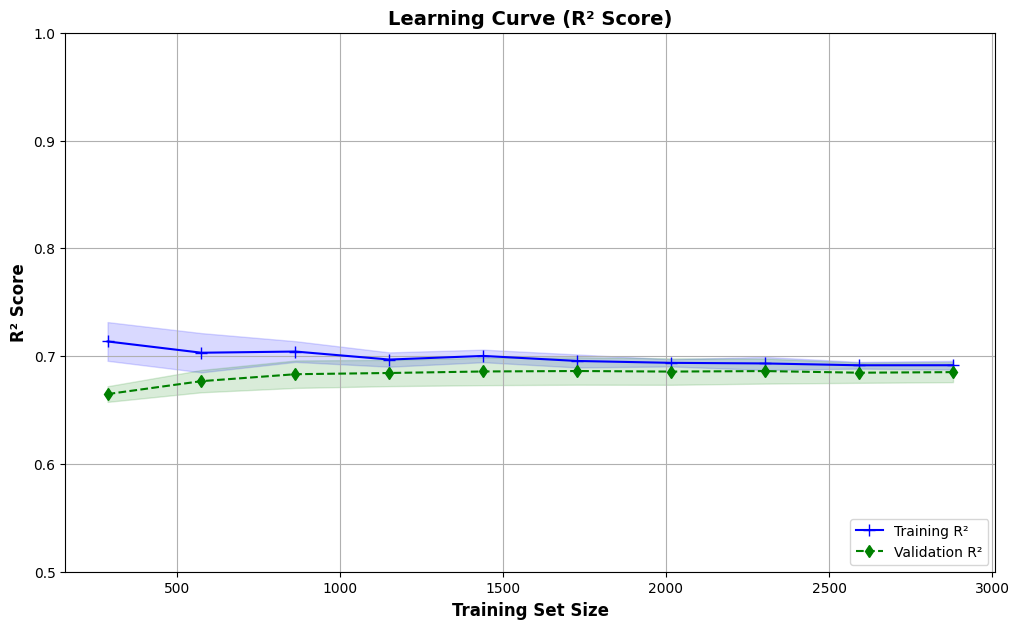

In [45]:
# Define the cross-validation strategy
cv_lc = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Learning curve computation
train_sizes, train_scores, test_scores = learning_curve(
    estimator=best_linear_model,
    X=X_train,
    y=y_train,
    train_sizes=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    cv=cv_lc,
    n_jobs=-1,
    scoring='r2'
)

# Compute means and standard deviations
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot the learning curve
fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot()

ax.plot(train_sizes, train_mean,
         color='blue', marker='+',
         markersize=8, label='Training R²')

ax.fill_between(train_sizes,
                 train_mean + train_std,
                 train_mean - train_std,
                 alpha=0.15, color='blue')

ax.plot(train_sizes, test_mean,
         color='green', linestyle='--',
         marker='d', markersize=6,
         label='Validation R²')

ax.fill_between(train_sizes,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')

ax.grid()
ax.set_xlabel('Training Set Size', fontsize=12, fontweight='bold')
ax.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax.set_title('Learning Curve (R² Score)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.set_ylim([0.5, 1.0])
plt.show()


**Full Convergence**: 
The `Training Score` and `Validation Score` curves closely approach each other (nearly overlapping). This visual pattern confirms the reduced generalization gap that we previously anticipated.

**Low Overfitting**:
The fact that the test score (0.66) is nearly identical to the training score confirms that the model has learned the underlying general patterns rather than memorizing the training data.

**Data Plateau**: 
The Learning Curve rapidly reached a plateau, suggesting that the dataset size is well-aligned with the complexity of the chosen model. The immediate convergence between training and validation scores confirms the absence of high variance, allowing the extracted coefficients to be interpreted as stable and reliable indicators of the key productivity drivers.

## Residual Analysis

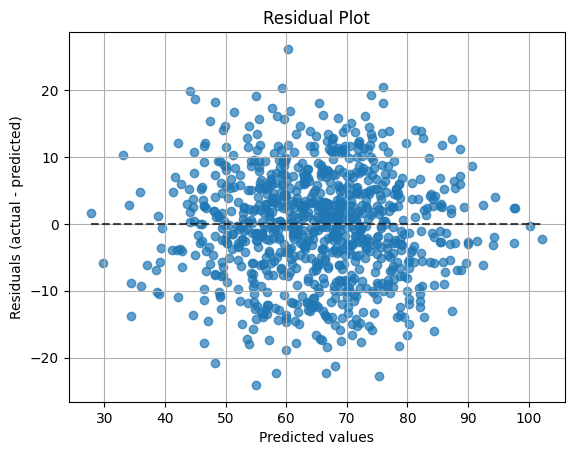

In [46]:
# Use the best trained model from the final evaluation
y_pred_test = best_linear_model.predict(X_test)

# Plot residuals
display = PredictionErrorDisplay.from_predictions(
    y_true=y_test,
    y_pred=y_pred_test,
    kind="residual_vs_predicted",
    scatter_kwargs={'alpha': 0.7}
)
display.ax_.set_title("Residual Plot")
plt.grid(True)
plt.show()



The residual plot of the regression model exhibits a random, uniform distribution of points centered around the zero-line, indicating that the **assumption of linearity has been met**. There are no discernible patterns which suggests that the model is free from significant non-linear relationships and heteroscedasticity. The consistent vertical spread of residuals across the range of predicted values (from approximately 30 to 100) confirms that the error variance is constant. 

Overall, the plot validates that a linear model is an appropriate fit for this dataset.


## Conclusion

This project provides a data-driven exploration into the digital transformation of the modern professional environment. By leveraging a dataset of 4,500 employee records, we developed a regression-based machine learning pipeline designed to quantify the intricate relationship between human work habits and Artificial Intelligence integration.

**Methodological Rigor and Data Integrity**
The project followed a principled approach to feature selection, prioritizing model generalizability over simple curve-fitting. By systematically removing high-cardinality identifiers (like `Employee_ID`) and variables that would lead to data leakage (such as wellness metrics derived from the target), we ensured that the resulting models learned the underlying causal patterns of productivity rather than noise or redundant information. The symmetrical, near-normal distribution of the target variable validated the stability of the dataset, providing a sound statistical foundation for regression analysis.

**Comparative Algorithm Analysis**
The investigation tested the hypothesis that employee productivity is influenced by non-linear interactions between variables like deep-work hours, AI tool leverage, and task complexity. Our comparative results confirmed this:
- While linear models provided a baseline, ensemble methods—specifically XGBoost and Random Forest—showed superior predictive power.
- The high performance of these tree-based models suggests that productivity is not merely a sum of its parts but an emergent property of how technological automation interacts with human cognitive focus.

- The final model achieved an R² Score of 0.6735 effectively capturing 67% of the variance in workplace output across diverse job roles.
**R² Score**: 0.6735
**MAE**: 6.4365
**RMSE**: 8.0587

To better understand the learning behavior of the model, we plotted a learning curve using R² as the evaluation metric. The curve showed high and converging performance on both the training and validation sets, suggesting low bias and low variance — a well-generalized model.

Lastly, we performed a residual analysis, which confirmed that the residuals were centered around zero without clear patterns, indicating that the model’s predictions are not systematically biased.

Overall, this project demonstrates a comprehensive machine learning workflow: from thoughtful preprocessing and model selection, to interpretability and evaluation. The final model is both accurate and generalizable, and could serve as a solid baseline for future developments in AI workplace productivity